# Cycle-level 오토인코더 v3 — 피처 정리 + 정규화

`Cycle_AE_v2.ipynb`(31피처, 정규화 없음)에서 두 가지를 바꿨다.

**1) 피처 8개 제거 → 23개**

| 뺀 피처 | 근거 |
|---|---|
| `Ana_Out_mean` | `SV_mean`과 상관 **1.000** (제어출력은 설정값의 함수) |
| `FT_max` | `SV_mean` 0.997 / `FT_mean` 0.988 |
| `PT_max` | `PT_mean` 0.992 |
| `Ramp_Negative_Slope_Count` | 이상 422건 중 1위 범인 1건뿐, 실제 이슈로 안 이어짐 |
| `Unexplained_PT_Dip_Count` / `_Max` | 유출은 이번 모델에서 다루지 않기로 함 |
| `Unexplained_FT_Dip_Count` / `_Max` | 같음 |

**2) 시작 조건에 끌려다니는 피처 6개를 표준화 잔차로 교체**

`Decay_Slope_PT` 같은 피처는 끄기 직전 압력이 높을수록 가파르다(상관 −0.530).
그대로 쓰면 "유독 빨리 샜다"와 "그냥 시작 압력이 높았다"가 구분되지 않는다.
자세한 근거와 실측 비교는 `Cycle_Normalizer.py` 주석과 `Cycle_Features_설명서.ipynb` 참고.

**바뀌지 않은 것**: 기간 분리, 제외 규칙(23:50~07:00 / AL_Line_Bit / Prev_SV==0),
학습 방식(lr 5e-4 + 스케줄러 + Early Stopping), 임계치 산출(Train 99퍼센타일).

맨 아래에서 **v2와 같은 데이터로 직접 비교**한다.

In [1]:
import os, sys
ROOT_DIR = os.path.dirname(os.getcwd())
sys.path.insert(0, ROOT_DIR); sys.path.insert(0, os.getcwd())

import numpy as np, pandas as pd, torch, joblib
import torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib, matplotlib.pyplot as plt

matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

from Log_Extractor import LogExtractor
from Cycle_Feature_Extractor import (extract_cycle_features, PUMP_MAP,
                                     DAILY_EXCLUDE_START, DAILY_EXCLUDE_END)
from Cycle_Normalizer import ResidualNormalizer, NORMALIZE_SPECS, SUFFIX
from Cycle_AE import CycleAutoencoder

ENV_PATH = os.path.join(ROOT_DIR, ".env")
MODEL_DIR = os.path.join(os.getcwd(), "models_v3")
os.makedirs(MODEL_DIR, exist_ok=True)

## 1. 설정

In [2]:
PUMP_ID = "P1"
info = PUMP_MAP[PUMP_ID]
HEAD, ROBOT, SLOT = info["head"], info["robot"], info["slot"]
print(f"{PUMP_ID} -> 헤드 {HEAD}, 로봇 {ROBOT}, 사출신호 Shot_Injection_{HEAD}_P{SLOT}")
print(f"야간 제외 구간: {DAILY_EXCLUDE_START} ~ {DAILY_EXCLUDE_END}")

TRAIN_START, TRAIN_END = "2026-09-10T07:00:00Z", "2026-09-18T07:00:00Z"
VALID_START, VALID_END = "2026-09-18T07:00:00Z", "2026-09-19T07:00:00Z"
TEST_START,  TEST_END  = "2026-09-20T19:00:00Z", "2026-09-23T18:00:00Z"   # 6일 고정 (now() 로 두면 실행할 때마다 범위가 달라져 비교가 어긋난다)

TARGET_TAGS = [
    f"Pump_BuildUp_{PUMP_ID}", f"g_s_SV_{PUMP_ID}", f"Scale_Out___FT_{PUMP_ID}",
    f"Scale_Out___PT_{PUMP_ID}", f"Ana_Out_{PUMP_ID}", f"TK_Temp_PV_{info['tank']}",
    f"Hz_Out_{PUMP_ID}", f"Shot_Injection_{HEAD}_P{SLOT}", f"{ROBOT}_Robot_Num",
    "AL_Line_Bit",
] + [f"{HEAD}_FOAMING_SHOT{k}" for k in range(1, 7)]

P1 -> 헤드 HD1, 로봇 RB1, 사출신호 Shot_Injection_HD1_P1
야간 제외 구간: 23:50 ~ 07:00


## 2. 모델에 넣을 피처 23개

피처는 **31개 전부 계산해서 저장**하고, 모델 입력만 골라 쓴다. 나중에 실제 고장이
발생하면 빼둔 피처들이 미리 반응했는지 사후에 확인할 수 있다.

In [3]:
RAW_COLS = [
    "N_Ticks", "SV_mean", "FT_mean", "PT_mean", "PT_std", "Temp_mean",
    "Prev_SV", "Prev_SV_Diff", "PreBuildUp_PT", "PreBuildUp_FT", "PT_Jump_From_Pre",
    "Instant_FT_Error_Rate_mean", "Instant_FT_Error_Rate_max",
    "RampUp_Time_Sec", "DeltaP_over_Q", "Steady_Std_PT", "Steady_Std_FT",
]
NORM_COLS = [t + SUFFIX for t in NORMALIZE_SPECS]     # 6개
FEATURE_COLS = RAW_COLS + NORM_COLS

# 정규화에 필요한 원본/기준 컬럼 (결측 확인용)
NEEDED = set(RAW_COLS) | set(NORMALIZE_SPECS) | {d for ds in NORMALIZE_SPECS.values() for d in ds}

print(f"모델 입력 {len(FEATURE_COLS)}개 = 원본 {len(RAW_COLS)} + 정규화 {len(NORM_COLS)}")
for t, ds in NORMALIZE_SPECS.items():
    print(f"   {t+SUFFIX:26s} <- {t} 에서 {', '.join(ds)} 영향 제거")

모델 입력 23개 = 원본 17 + 정규화 6
   Decay_Slope_PT_z           <- Decay_Slope_PT 에서 PT_at_End 영향 제거
   Decay_Slope_FT_z           <- Decay_Slope_FT 에서 FT_at_End 영향 제거
   FT_Jump_From_Pre_z         <- FT_Jump_From_Pre 에서 PreBuildUp_FT 영향 제거
   Cum_FT_Error_z             <- Cum_FT_Error 에서 SV_mean, N_Ticks 영향 제거
   FT_std_z                   <- FT_std 에서 FT_mean 영향 제거
   Current_Proxy_I_z          <- Current_Proxy_I 에서 PT_mean 영향 제거


## 3. 데이터 추출

In [4]:
extractor = LogExtractor(env_path=ENV_PATH)

def build(start, end, label):
    raw = extractor.get_data(start_time=start, end_time=end, target_tags=TARGET_TAGS)
    cyc, _ = extract_cycle_features(raw, PUMP_ID)
    print(f"[{label}] raw {len(raw):,}행 -> 사이클 {len(cyc):,}개 "
          f"(제외 대상 {int(cyc['Excluded'].sum())}개)")
    return cyc

train_cyc = build(TRAIN_START, TRAIN_END, "Train")
valid_cyc = build(VALID_START, VALID_END, "Valid")
test_cyc  = build(TEST_START,  TEST_END,  "Test")

🔌 [Extractor] InfluxDB 분석용 추출기 연결 완료!
🚀 추출 시작: 2026-09-10T07:00:00+00:00 ~ 2026-09-18T07:00:00+00:00
   태그 16개 · 앞쪽 600초는 결측 복원용으로 더 받습니다
📦 [Chunk] 2026-09-10T06:50:00Z ~ 2026-09-10T12:50:00Z ... 

39428행
📦 [Chunk] 2026-09-10T12:50:00Z ~ 2026-09-10T18:50:00Z ... 

35983행
📦 [Chunk] 2026-09-10T18:50:00Z ~ 2026-09-11T00:50:00Z ... 

37083행
📦 [Chunk] 2026-09-11T00:50:00Z ~ 2026-09-11T06:50:00Z ... 

38257행
📦 [Chunk] 2026-09-11T06:50:00Z ~ 2026-09-11T12:50:00Z ... 

...

8461행
📦 [Chunk] 2026-09-26T18:50:00Z ~ 2026-09-27T00:50:00Z ... 

8377행
📦 [Chunk] 2026-09-27T00:50:00Z ~ 2026-09-27T05:54:31Z ... 

20476행


✅ 통합 완료 — 858368행 × 17컬럼
🌡️  온도 계열 컬럼 1개 — **단위가 태그마다 다르다.**
     TK_Temp_PV_P1            Scale_Max___TT_P1=1000 → 0.1℃ 단위, 값÷10
     ※ 2026-04 데이터는 Scale_Max___TT_P1=100 이었다. 지금은 1000 이라
       같은 태그가 22 → 228 로 찍힌다. 두 시기를 섞지 말 것.


[Test] raw 858,368행 -> 사이클 9,126개 (제외 대상 176개)


In [5]:
def clean(cyc, drop_excluded=True):
    out = cyc.copy()
    if drop_excluded:
        out = out[~out["Excluded"]]
    n_cold = int((out["Prev_SV"] == 0).sum())
    if n_cold:
        out = out[out["Prev_SV"] != 0]
    before = len(out)
    out = out.dropna(subset=sorted(NEEDED))
    if before != len(out):
        print(f"  결측으로 {before - len(out)}개 제외")
    return out

train_clean = clean(train_cyc)
valid_clean = clean(valid_cyc)
test_clean  = clean(test_cyc, drop_excluded=False)
print(f"Train {len(train_clean):,} / Valid {len(valid_clean):,} / Test {len(test_clean):,}")

  결측으로 185개 제외
  결측으로 19개 제외
  결측으로 15개 제외
Train 20,524 / Valid 2,934 / Test 9,110


## 4. 정규화 — 학습 구간에서만 적합

각 피처마다 두 개의 회귀를 학습 구간으로 적합한다.

1. `예상값 = a·기준변수 + b` (위치)
2. `예상흩어짐 = sa·기준변수 + sb` (폭)
3. 피처 = `(실제 − 예상값) ÷ 예상흩어짐`

Valid/Test 에는 학습 구간에서 얻은 식을 **그대로 적용**한다. 전체로 적합하면
"학습 때와 달라진 정도"가 0으로 눌려 보이지 않게 된다.

In [6]:
norm = ResidualNormalizer()
norm.fit(train_clean)
train_n = norm.transform(train_clean)
valid_n = norm.transform(valid_clean)
test_n  = norm.transform(test_clean)

joblib.dump(norm, os.path.join(MODEL_DIR, f"normalizer_{PUMP_ID}.pkl"))

print("정규화 검증 — 기준변수와의 상관이 0 에 가까워야 성공\n")
print(norm.report(train_n).to_string(index=False))

정규화 검증 — 기준변수와의 상관이 0 에 가까워야 성공

              피처          기준변수  원본 상관  정규화 후 상관  정규화 후 평균  정규화 후 표준편차
  Decay_Slope_PT     PT_at_End -0.537     0.007    -0.001       0.947
  Decay_Slope_FT     FT_at_End -0.883    -0.001     0.000       1.098
FT_Jump_From_Pre PreBuildUp_FT -0.520    -0.000     0.000       1.533
    Cum_FT_Error       SV_mean  0.899     0.005    -0.001       0.986
          FT_std       FT_mean  0.872     0.018    -0.006       1.032
 Current_Proxy_I       PT_mean  0.997    -0.001     0.000       1.011


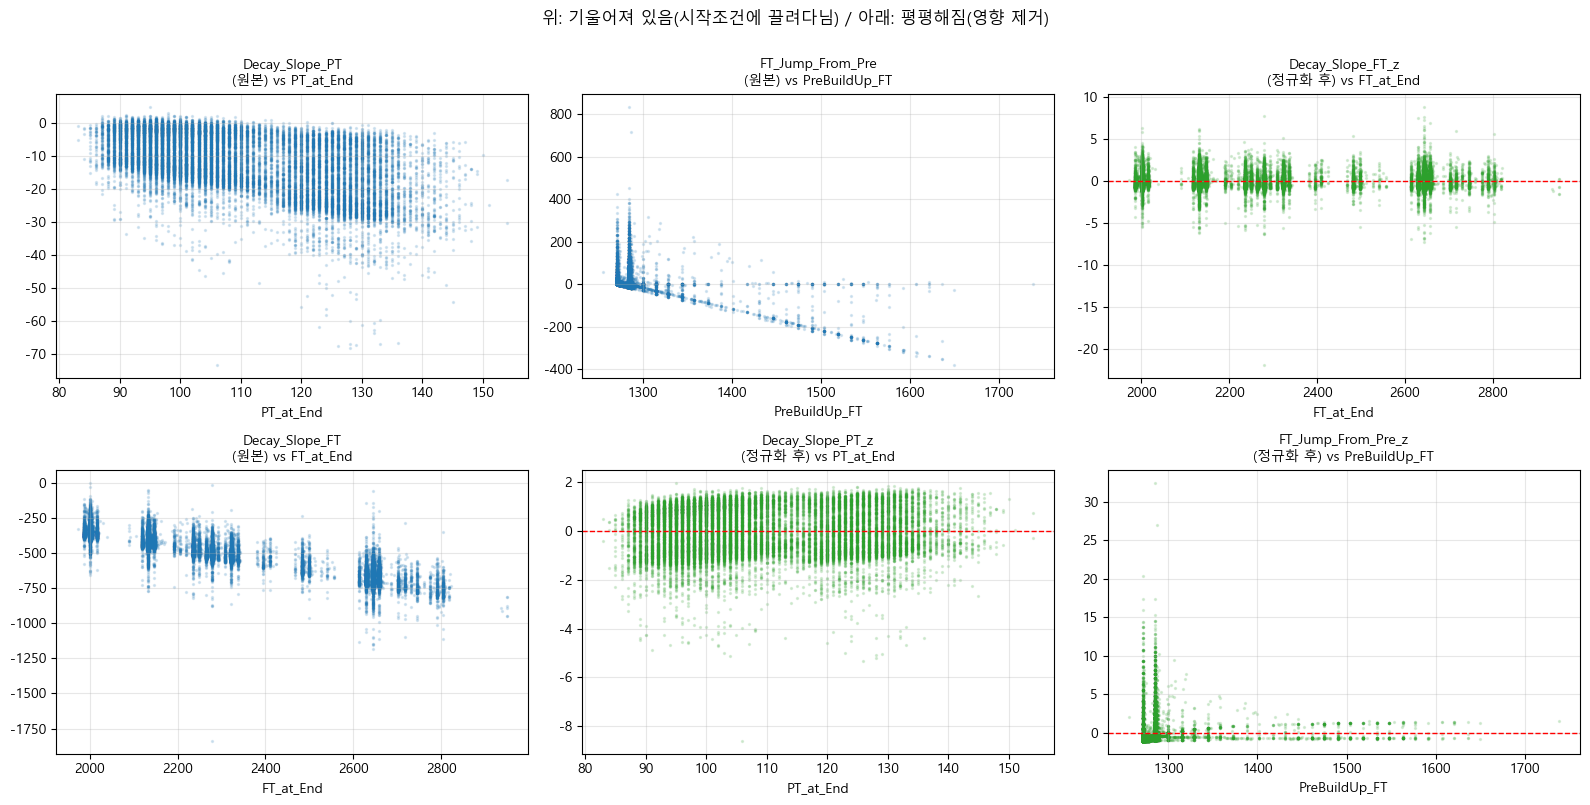

In [7]:
# 정규화 전후 비교 그림
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, (target, drivers) in zip(axes.T.ravel()[:3], list(NORMALIZE_SPECS.items())[:3]):
    d = drivers[0]
    ax.scatter(train_n[d], train_n[target], s=2, alpha=.15, color="tab:blue")
    ax.set_title(f"{target}\n(원본) vs {d}", fontsize=10)
    ax.set_xlabel(d); ax.grid(alpha=.3)
for ax, (target, drivers) in zip(axes.T.ravel()[3:6], list(NORMALIZE_SPECS.items())[:3]):
    d = drivers[0]
    ax.scatter(train_n[d], train_n[target + SUFFIX], s=2, alpha=.15, color="tab:green")
    ax.axhline(0, color="red", ls="--", lw=1)
    ax.set_title(f"{target}{SUFFIX}\n(정규화 후) vs {d}", fontsize=10)
    ax.set_xlabel(d); ax.grid(alpha=.3)
fig.suptitle("위: 기울어져 있음(시작조건에 끌려다님) / 아래: 평평해짐(영향 제거)", y=1.00)
plt.tight_layout(); plt.show()

## 5. 스케일링 + 학습

In [8]:
scaler = StandardScaler()
X_train = scaler.fit_transform(train_n[FEATURE_COLS])
X_valid = scaler.transform(valid_n[FEATURE_COLS])
X_test  = scaler.transform(test_n[FEATURE_COLS])
joblib.dump(scaler, os.path.join(MODEL_DIR, f"scaler_cycle_{PUMP_ID}.pkl"))

train_loader = DataLoader(TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(X_train)),
                          batch_size=64, shuffle=True)
valid_loader = DataLoader(TensorDataset(torch.FloatTensor(X_valid), torch.FloatTensor(X_valid)),
                          batch_size=64, shuffle=False)
print(X_train.shape, X_valid.shape, X_test.shape)

(20524, 23) (2934, 23) (9110, 23)


In [9]:
torch.manual_seed(42)
model = CycleAutoencoder(input_dim=len(FEATURE_COLS))
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=10)

EPOCHS, PATIENCE = 400, 40
best_val, best_epoch, wait = float("inf"), 0, 0
model_path = os.path.join(MODEL_DIR, f"autoencoder_cycle_{PUMP_ID}.pth")
hist = []

for epoch in range(1, EPOCHS + 1):
    model.train(); tr = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad(); loss = criterion(model(xb), yb)
        loss.backward(); optimizer.step(); tr += loss.item()
    tr /= len(train_loader)

    model.eval(); va = 0.0
    with torch.no_grad():
        for xb, yb in valid_loader:
            va += criterion(model(xb), yb).item()
    va /= len(valid_loader)
    scheduler.step(va)
    hist.append((epoch, tr, va, optimizer.param_groups[0]["lr"]))

    if va < best_val - 1e-5:
        best_val, best_epoch, wait = va, epoch, 0
        torch.save(model.state_dict(), model_path)
    else:
        wait += 1
    if epoch % 20 == 0 or epoch == 1:
        star = "  *best*" if best_epoch == epoch else ""
        print(f"Epoch {epoch:03d} | Train {tr:.4f} | Valid {va:.4f} | "
              f"lr {optimizer.param_groups[0]['lr']:.1e}{star}")
    if wait >= PATIENCE:
        print(f"\nEarly stopping (epoch {epoch}, best={best_epoch})"); break

print(f"\n최종 best Valid Loss: {best_val:.4f} (epoch {best_epoch})")
model.load_state_dict(torch.load(model_path, weights_only=True))

Epoch 001 | Train 0.7521 | Valid 0.4806 | lr 5.0e-04  *best*


Epoch 020 | Train 0.1159 | Valid 0.1246 | lr 5.0e-04


Epoch 040 | Train 0.0966 | Valid 0.1042 | lr 5.0e-04


Epoch 060 | Train 0.0896 | Valid 0.0993 | lr 5.0e-04


Epoch 080 | Train 0.0861 | Valid 0.0920 | lr 2.5e-04


Epoch 100 | Train 0.0846 | Valid 0.0895 | lr 1.3e-04


Epoch 120 | Train 0.0839 | Valid 0.0904 | lr 3.1e-05



Early stopping (epoch 130, best=90)

최종 best Valid Loss: 0.0878 (epoch 90)


<All keys matched successfully>

## 6. 재구성오차 & 임계치

In [10]:
def recon(X):
    model.eval()
    with torch.no_grad():
        t = torch.FloatTensor(X); pf = ((t - model(t)) ** 2).numpy()
    return pf.mean(axis=1), pf

train_err, train_pf = recon(X_train)
valid_err, _ = recon(X_valid)
test_err, test_pf = recon(X_test)

THRESHOLD = float(np.percentile(train_err, 99))
print(f"임계치 (Train 99퍼센타일): {THRESHOLD:.4f}\n")
for name, err in [("Train", train_err), ("Valid", valid_err), ("Test", test_err)]:
    over = err > THRESHOLD
    print(f"{name:6s} | 평균 {err.mean():.4f} | 중앙값 {np.median(err):.4f} | "
          f"최대 {err.max():.4f} | 임계치 초과 {over.sum():,}건 ({over.mean()*100:.2f}%)")

임계치 (Train 99퍼센타일): 0.3471

Train  | 평균 0.0849 | 중앙값 0.0660 | 최대 5.7251 | 임계치 초과 206건 (1.00%)
Valid  | 평균 0.0878 | 중앙값 0.0681 | 최대 1.8960 | 임계치 초과 42건 (1.43%)
Test   | 평균 0.0957 | 중앙값 0.0750 | 최대 2.3170 | 임계치 초과 168건 (1.84%)


In [11]:
res = test_n.copy()
res["Recon_Error"] = test_err
anomalies = res[res["Recon_Error"] > THRESHOLD].sort_values("Recon_Error", ascending=False)
print(f"Test {len(res):,} 사이클 중 이상 {len(anomalies):,}건 ({len(anomalies)/len(res)*100:.2f}%)\n")
for rank, (idx, row) in enumerate(anomalies.head(10).iterrows(), 1):
    pos = res.index.get_loc(idx)
    contrib = pd.Series(test_pf[pos], index=FEATURE_COLS)
    contrib = (contrib / contrib.sum() * 100).sort_values(ascending=False)
    print(f"[#{rank}] {row['Start_Time']} | 오차 {row['Recon_Error']:.3f}")
    for f, v in contrib.head(3).items():
        print(f"      - {f}: {v:.1f}%  (값 {row[f]:.3f})")

Test 9,110 사이클 중 이상 168건 (1.84%)

[#1] 2026-09-23 07:04:07.024733 | 오차 2.317
      - Decay_Slope_FT_z: 32.4%  (값 -3.668)
      - Decay_Slope_PT_z: 21.3%  (값 1.308)
      - PreBuildUp_FT: 19.1%  (값 1431.000)
[#2] 2026-09-23 09:55:31.977711 | 오차 1.403
      - Decay_Slope_FT_z: 21.5%  (값 9.647)
      - FT_std_z: 15.4%  (값 -0.044)
      - Steady_Std_FT: 13.5%  (값 245.302)
[#3] 2026-09-21 20:45:30.880300 | 오차 1.318
      - Decay_Slope_FT_z: 54.0%  (값 5.544)
      - Decay_Slope_PT_z: 14.6%  (값 -1.776)
      - RampUp_Time_Sec: 14.3%  (값 1.584)
[#4] 2026-09-23 12:02:22.993962 | 오차 1.209
      - FT_std_z: 37.8%  (값 -6.758)
      - RampUp_Time_Sec: 16.4%  (값 0.000)
      - Decay_Slope_FT_z: 11.8%  (값 -1.021)
[#5] 2026-09-23 10:34:43.023630 | 오차 1.045
      - Decay_Slope_FT_z: 54.3%  (값 4.528)
      - Decay_Slope_PT_z: 15.9%  (값 -2.176)
      - RampUp_Time_Sec: 14.0%  (값 1.546)
[#6] 2026-09-21 09:27:10.889554 | 오차 0.897
      - RampUp_Time_Sec: 32.2%  (값 1.523)
      - Steady_Std_FT: 19.5%  (값 42

In [12]:
per_feat_err = pd.Series(train_pf.mean(axis=0), index=FEATURE_COLS).sort_values()
print("피처별 평균 재구성오차 (1.0 = 전혀 못 맞힘)")
print(per_feat_err.to_string())

anom_mask = test_err > THRESHOLD
contrib_all = (test_pf / test_pf.sum(axis=1, keepdims=True) * 100)[anom_mask]
print("\n이상 건에서의 평균 기여도")
print(pd.Series(contrib_all.mean(axis=0), index=FEATURE_COLS).sort_values(ascending=False).round(1).to_string())

피처별 평균 재구성오차 (1.0 = 전혀 못 맞힘)
Prev_SV_Diff                  0.004964
Prev_SV                       0.008699
SV_mean                       0.012481
FT_mean                       0.014291
PT_mean                       0.015643
Instant_FT_Error_Rate_max     0.018419
Instant_FT_Error_Rate_mean    0.026526
Current_Proxy_I_z             0.030009
PT_std                        0.034171
Cum_FT_Error_z                0.035471
PT_Jump_From_Pre              0.042896
PreBuildUp_FT                 0.051195
Decay_Slope_PT_z              0.075421
Steady_Std_FT                 0.083468
FT_std_z                      0.084122
FT_Jump_From_Pre_z            0.092600
N_Ticks                       0.117412
RampUp_Time_Sec               0.127003
Decay_Slope_FT_z              0.151019
DeltaP_over_Q                 0.165572
PreBuildUp_PT                 0.197838
Steady_Std_PT                 0.275353
Temp_mean                     0.288850

이상 건에서의 평균 기여도
Decay_Slope_FT_z              17.700001
RampUp_Time_Sec   

## 7. v2 와 직접 비교

**같은 사이클 집합**에 v2 모델(31피처, 정규화 없음)과 v3 모델을 각각 적용해서
무엇이 달라졌는지 본다.

In [13]:
V2_DIR = os.path.join(os.getcwd(), "models_v2")
V2_COLS = ['N_Ticks','SV_mean','FT_mean','FT_max','FT_std','PT_mean','PT_max','PT_std',
    'Ana_Out_mean','Temp_mean','Prev_SV','Prev_SV_Diff','PreBuildUp_PT','PreBuildUp_FT',
    'PT_Jump_From_Pre','FT_Jump_From_Pre','Instant_FT_Error_Rate_mean','Instant_FT_Error_Rate_max',
    'Cum_FT_Error','RampUp_Time_Sec','DeltaP_over_Q','Current_Proxy_I','Steady_Std_PT','Steady_Std_FT',
    'Ramp_Negative_Slope_Count','Unexplained_PT_Dip_Count','Unexplained_PT_Dip_Max',
    'Unexplained_FT_Dip_Count','Unexplained_FT_Dip_Max','Decay_Slope_PT','Decay_Slope_FT']

ok = all(os.path.exists(os.path.join(V2_DIR, f)) for f in
         [f"scaler_cycle_{PUMP_ID}.pkl", f"autoencoder_cycle_{PUMP_ID}.pth"])
if not ok:
    print("v2 모델 파일이 없습니다 - Cycle_AE_v2.ipynb 를 먼저 실행하세요")
else:
    sc2 = joblib.load(os.path.join(V2_DIR, f"scaler_cycle_{PUMP_ID}.pkl"))
    m2 = CycleAutoencoder(len(V2_COLS))
    m2.load_state_dict(torch.load(os.path.join(V2_DIR, f"autoencoder_cycle_{PUMP_ID}.pth"),
                                  weights_only=True))
    m2.eval()

    def recon_v2(df):
        X = sc2.transform(df[V2_COLS])
        with torch.no_grad():
            t = torch.FloatTensor(X); pf = ((t - m2(t)) ** 2).numpy()
        return pf.mean(axis=1)

    tr2, te2 = recon_v2(train_n), recon_v2(test_n)
    TH2 = float(np.percentile(tr2, 99))

    cmp = pd.DataFrame({
        "항목": ["모델 입력 피처 수", "정규화", "임계치",
                 "Train 초과율(%)", "Test 초과율(%)", "Test 이상 건수"],
        "v2": [len(V2_COLS), "없음", round(TH2, 4),
               round((tr2 > TH2).mean()*100, 2), round((te2 > TH2).mean()*100, 2),
               int((te2 > TH2).sum())],
        "v3": [len(FEATURE_COLS), "표준화 잔차 6개", round(THRESHOLD, 4),
               round((train_err > THRESHOLD).mean()*100, 2),
               round((test_err > THRESHOLD).mean()*100, 2),
               int((test_err > THRESHOLD).sum())],
    })
    print(cmp.to_string(index=False))

    a2, a3 = te2 > TH2, test_err > THRESHOLD
    print(f"\n둘 다 이상으로 본 사이클 : {int((a2 & a3).sum()):4d}")
    print(f"v2 만 이상               : {int((a2 & ~a3).sum()):4d}")
    print(f"v3 만 이상               : {int((~a2 & a3).sum()):4d}")
    print(f"두 모델 오차의 상관       : {np.corrcoef(te2, test_err)[0,1]:.3f}")

          항목      v2        v3
  모델 입력 피처 수      31        23
         정규화      없음 표준화 잔차 6개
         임계치  0.3167    0.3471
Train 초과율(%)     1.0       1.0
 Test 초과율(%)    1.99      1.84
  Test 이상 건수     181       168

둘 다 이상으로 본 사이클 :   91
v2 만 이상               :   90
v3 만 이상               :   77
두 모델 오차의 상관       : 0.619


            v2 이상률%  v3 이상률%  사이클수
Date                              
2026-09-21     1.79     1.59  2961
2026-09-22     2.28     1.92  3330
2026-09-23     1.84     2.02  2819


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


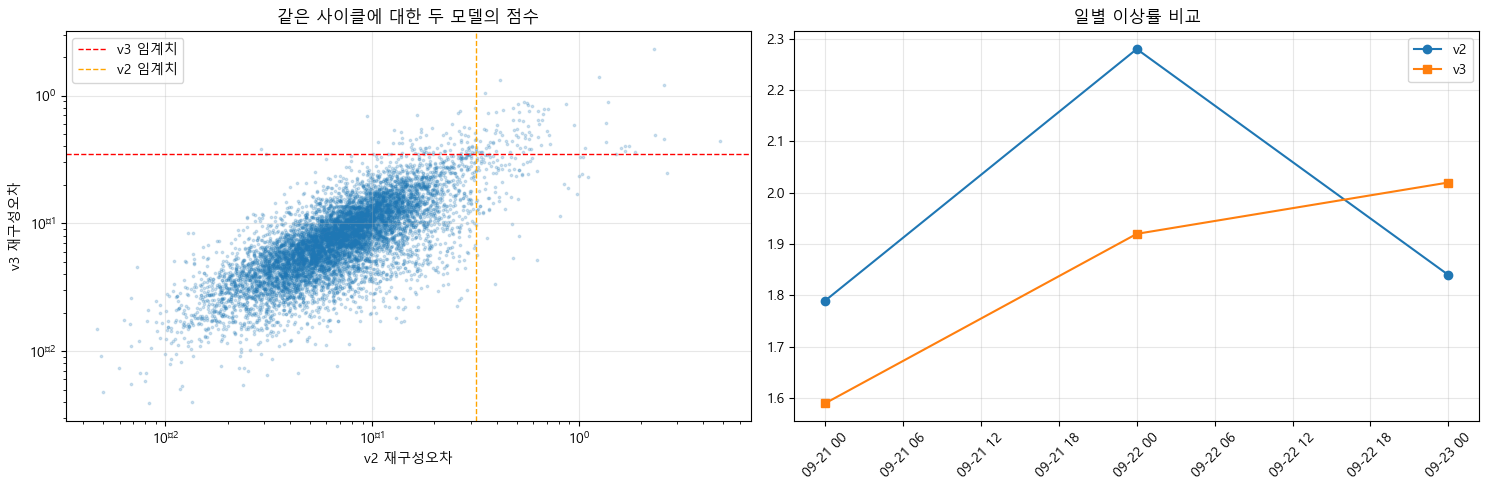

In [14]:
if ok:
    d = res[["Start_Time"]].copy()
    d["v3"] = test_err; d["v2"] = te2
    d["Date"] = pd.to_datetime(d["Start_Time"]).dt.date
    daily = pd.DataFrame({
        "v2 이상률%": d.groupby("Date").apply(lambda g: (g["v2"] > TH2).mean()*100),
        "v3 이상률%": d.groupby("Date").apply(lambda g: (g["v3"] > THRESHOLD).mean()*100),
        "사이클수": d.groupby("Date").size(),
    }).round(2)
    print(daily.to_string())

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].scatter(te2, test_err, s=3, alpha=.2)
    axes[0].axhline(THRESHOLD, color="red", ls="--", lw=1, label="v3 임계치")
    axes[0].axvline(TH2, color="orange", ls="--", lw=1, label="v2 임계치")
    axes[0].set_xlabel("v2 재구성오차"); axes[0].set_ylabel("v3 재구성오차")
    axes[0].set_title("같은 사이클에 대한 두 모델의 점수")
    axes[0].set_xscale("log"); axes[0].set_yscale("log")
    axes[0].legend(); axes[0].grid(alpha=.3)

    axes[1].plot(daily.index, daily["v2 이상률%"], marker="o", label="v2")
    axes[1].plot(daily.index, daily["v3 이상률%"], marker="s", label="v3")
    axes[1].set_title("일별 이상률 비교"); axes[1].legend(); axes[1].grid(alpha=.3)
    plt.setp(axes[1].get_xticklabels(), rotation=45)
    plt.tight_layout(); plt.show()

## 8. 학습 곡선 & 분포

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


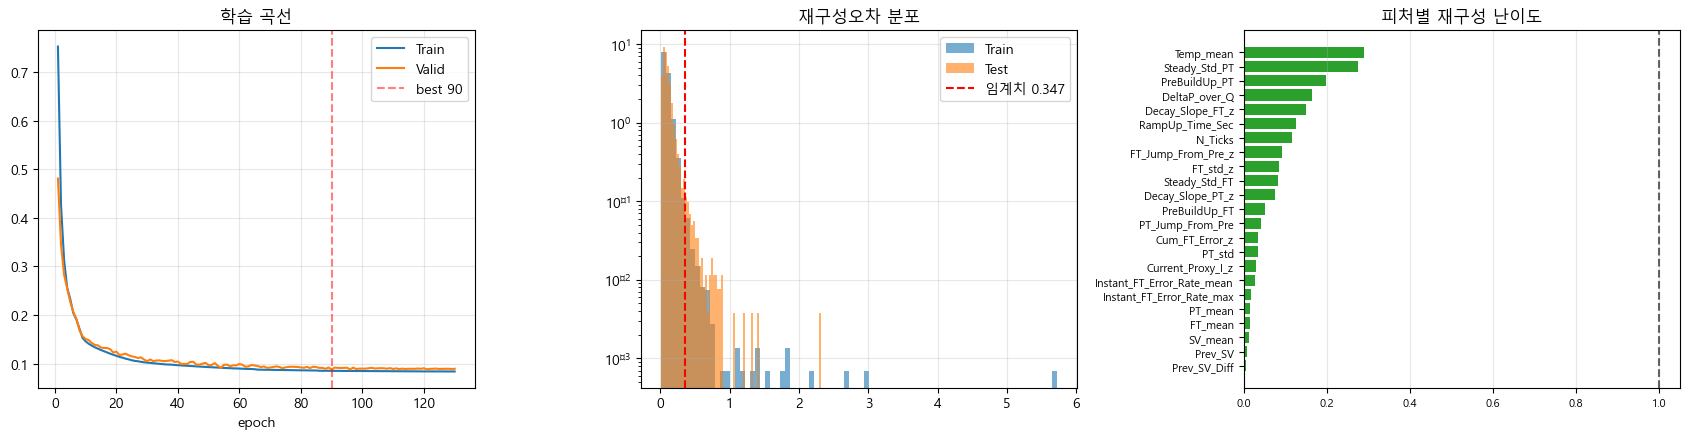

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
h = pd.DataFrame(hist, columns=["epoch", "train", "valid", "lr"])
axes[0].plot(h["epoch"], h["train"], label="Train")
axes[0].plot(h["epoch"], h["valid"], label="Valid")
axes[0].axvline(best_epoch, color="red", ls="--", alpha=.5, label=f"best {best_epoch}")
axes[0].set_title("학습 곡선"); axes[0].set_xlabel("epoch"); axes[0].legend(); axes[0].grid(alpha=.3)

axes[1].hist(train_err, bins=80, alpha=.6, label="Train", density=True)
axes[1].hist(test_err, bins=80, alpha=.6, label="Test", density=True)
axes[1].axvline(THRESHOLD, color="red", ls="--", label=f"임계치 {THRESHOLD:.3f}")
axes[1].set_yscale("log"); axes[1].set_title("재구성오차 분포")
axes[1].legend(); axes[1].grid(alpha=.3)

colors = ["tab:green" if v < 0.3 else "tab:orange" if v < 0.7 else "tab:red" for v in per_feat_err.values]
axes[2].barh(per_feat_err.index, per_feat_err.values, color=colors)
axes[2].axvline(1.0, color="black", ls="--", alpha=.6)
axes[2].set_title("피처별 재구성 난이도"); axes[2].tick_params(labelsize=8); axes[2].grid(axis="x", alpha=.3)
plt.tight_layout(); plt.show()